## We left off from here

In [1]:
"""
End-to-end pipeline: CD133 E14 vs E18
DESeq2 -> Consensus Peaks -> Enhancer Integration -> CellOracle Base GRN -> GRN Pruning
"""

import os
import pandas as pd
import numpy as np
from importlib import reload
import pandas as pd 
import numpy as np 
import sys
import os
# get project root (two levels up from this notebook)
project_root = os.path.abspath(os.path.join(os.path.dirname('src'), '..'))
# if in notebook:
# project_root = os.path.abspath('..')   # or adjust as needed
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.pipeline as pipeline
import src.enhancer_atac as enatac
import src.grn_pruner as grnpruner
# Reload modules
reload(pipeline)
reload(enatac)
reload(grnpruner)

# ==============================================================================
# PATHS
# ==============================================================================

base_dir = "/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC"

paths = {
    # RNA-seq
    "counts": os.path.join(base_dir, "data/rna_seq/E14_ E18_LGE_cortex_seq_Counts.csv"),
    "metadata": os.path.join(base_dir, "data/rna_seq/Samples+Pooling_RNA-Seq.csv"),
    
    # ATAC-seq
    "atac_metadata": os.path.join(base_dir, "data/atac_seq/ATAC-seq/samples_all.csv"),
    "atac_peak_dir": os.path.join(base_dir, "data/atac_seq/ATAC-seq"),
    
    # Annotations
    "tf_list": os.path.join(base_dir, "data/annotations/Mouse_TFs_Kinases_webpage-3-30-2017.xlsx"),
    "gtf": os.path.join(base_dir, "data/annotations/gencode.vM36.annotation.gtf"),
    "enhancer_files": [
        os.path.join(base_dir, "data/annotations/enhancerAtlas_neuron_cortical.txt"),
        # os.path.join(base_dir, "data/annotations/enhancerAtlas_brain_e14.5.txt"),
        os.path.join(base_dir, "data/annotations/enhancerAtlas_cortex.txt")
    ],
    
    # Integrated data (for pipeline object only)
    "overlap_df": os.path.join(base_dir, "data/integrated/overlap_annotated.tsv"),
    "chip_annotated": os.path.join(base_dir, "data/integrated/chip_annotated_filtered.tsv"),
    "atac_annotated": os.path.join(base_dir, "data/integrated/atac_annotated.tsv"),
    
    # Output paths
    "output_dir": os.path.join(base_dir, "results/cd133_e14_e18_grn"),
    "consensus_bed": os.path.join(base_dir, "results/cd133_e14_e18_grn/consensus_cd133.bed"),
    "deseq_output": os.path.join(base_dir, "results/cd133_e14_e18_grn/deseq_temporal_cd133.csv"),
    "celloracle_h5": os.path.join(base_dir, "results/cd133_e14_e18_grn/celloracle_tfinfo.h5"),
    "celloracle_parquet": os.path.join(base_dir, "results/cd133_e14_e18_grn/celloracle_base_grn.parquet"),
    "e14_grn": os.path.join(base_dir, "results/cd133_e14_e18_grn/E14_TF_network.csv"),
    "e18_grn": os.path.join(base_dir, "results/cd133_e14_e18_grn/E18_TF_network.csv")
}

# Create output directory
os.makedirs(paths["output_dir"], exist_ok=True)

exclude_samples = ['MUC9939', 'MUC9940', 'MUC9914']

print("="*80)
print("CD133 E14 vs E18 GRN PIPELINE")
print("="*80)

# ==============================================================================
# STEP 1: RNA-SEQ DIFFERENTIAL EXPRESSION (CD133 E14 vs E18)
# ==============================================================================

print("\n" + "="*80)
print("STEP 1: DIFFERENTIAL EXPRESSION ANALYSIS")
print("="*80)

nsc = pipeline.NSCAnalysis(
    counts_path=paths['counts'],
    metadata_path=paths['metadata'],
    atac_metadata_path=paths['atac_metadata'],
    overlap_df_path=paths['overlap_df'],
    chip_annotated_path=paths['chip_annotated'],
    atac_annotated_path=paths['atac_annotated'],
    tf_list_path=paths['tf_list'],
    gtf_path=paths['gtf'],
    exclude_samples=exclude_samples
)

# Filter for CD133 only
cd133_samples = nsc.metadata[nsc.metadata['Marker'] == 'Progenitors'].index.tolist()
nsc.counts = nsc.counts[[c for c in cd133_samples if c in nsc.counts.columns]]
nsc.metadata = nsc.metadata.loc[cd133_samples]

print(f"\nCD133 samples: {len(nsc.metadata)}")
print(nsc.metadata[['Stage', 'Region', 'Marker']].value_counts())

# Run DESeq2
deseq_results = nsc.run_deseq(group1='E14', group2='E18', group_col='Stage')

# Save DESeq results
deseq_results.to_csv(paths['deseq_output'])
print(f"\nDESeq results saved to: {paths['deseq_output']}")

# Get DE TFs
de_tfs = deseq_results[
    (deseq_results['padj'] < 0.05) & 
    (deseq_results['log2FoldChange'].abs() > 1) &
    (deseq_results['is_TF'] == True)
]

deg_list_e14 = de_tfs[de_tfs['log2FoldChange'] > 1]['symbol'].tolist()
deg_list_e18 = de_tfs[de_tfs['log2FoldChange'] < -1]['symbol'].tolist()

print(f"\nE14-high TFs: {len(deg_list_e14)}")
print(f"E18-high TFs: {len(deg_list_e18)}")
print(f"\nE14 TFs: {deg_list_e14[:10]}...")
print(f"E18 TFs: {deg_list_e18[:10]}...")


# ==============================================================================
# STEP 2: BUILD CONSENSUS PEAKS FROM ATAC-SEQ
# ==============================================================================

print("\n" + "="*80)
print("STEP 2: CONSENSUS PEAK BUILDING")
print("="*80)

builder = enatac.ConsensusPeakBuilder(
    metadata_file=paths['atac_metadata'],
    peak_dir=paths['atac_peak_dir'],
    factor='CD133',
    conditions=['E14', 'E18']
)

consensus = builder.build_consensus()
builder.save_bed(consensus, paths['consensus_bed'])

print(f"\nConsensus peaks: {len(consensus)}")
print(f"Saved to: {paths['consensus_bed']}")

# ==============================================================================
# STEP 3: ENHANCER INTEGRATION
# ==============================================================================

print("\n" + "="*80)
print("STEP 3: ENHANCER ATLAS INTEGRATION")
print("="*80)

integrator = enatac.EnhancerIntegrator(
    enhancer_files=paths['enhancer_files'],
    from_assembly='mm9'
)

enhancers_mm39 = integrator.load_and_liftover()

# Overlap with consensus peaks
target_genes, overlaps_df = integrator.overlap_with_consensus(consensus)

# Get DE TFs with accessible enhancers
e14_tfs_with_enh = integrator.get_de_with_accessible_enhancers(target_genes, deg_list_e14)
e18_tfs_with_enh = integrator.get_de_with_accessible_enhancers(target_genes, deg_list_e18)

print(f"\nE14 TFs with accessible enhancers: {e14_tfs_with_enh}")
print(f"E18 TFs with accessible enhancers: {e18_tfs_with_enh}")
# # Save enhancer overlaps
# overlaps_df.to_csv(os.path.join(paths['output_dir'], 'enhancer_consensus_overlaps.csv'), index=False)


/mnt/aiongpfs/users/adhal/micromamba/envs/scrna_target_idf/lib/python3.10/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


CD133 E14 vs E18 GRN PIPELINE

STEP 1: DIFFERENTIAL EXPRESSION ANALYSIS
Loading data...

[1/9] Loading counts...
      Dropping 1 genes with NaN values
      28664 genes x 36 samples

[2/9] Loading RNA-seq metadata...
      36 samples
      Columns: ['ForeignID', 'Stage', 'Replicate', 'Region', 'Marker', 'Shuffle']

[3/9] Loading ATAC-seq metadata...
      22 samples
      Columns: ['Tissue', 'Factor', 'Condition', 'Treatment', 'Replicate', 'bamReads', 'Peaks', 'PeakCaller']

[4/9] Creating ATAC-to-RNA sample mapping...
      Mapped: 21 / 22 ATAC samples
      Unmatched ATAC samples: ['ISF1064']

[5/9] Removing outlier samples...
      Removed: ['MUC9939', 'MUC9940', 'MUC9914']
      Remaining: 33 samples

[6/9] Filtering low-count genes...

Filtering low-count genes
Threshold: counts >= 10 in >= 3 samples
  E14: 17483 genes pass filter
  E18: 17939 genes pass filter

Genes before: 28664
Genes after:  18187
Removed:      10477 (36.6%)

[7/9] Loading overlap_df (ChIP ∩ ATAC)...
      44

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 26.24 seconds.

Fitting dispersion trend curve...
... done in 0.87 seconds.

Fitting MAP dispersions...
... done in 40.97 seconds.

Fitting LFCs...
... done in 13.19 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 14 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Extracting results (E14 vs E18)...


... done in 4.37 seconds.



Log2 fold change & Wald test p-value: Stage E14 vs E18
                        baseMean  log2FoldChange     lfcSE      stat  \
ENSMUSG00000000001  11392.735011        0.163045  0.071729  2.273084   
ENSMUSG00000000088   7290.014219        0.374888  0.087763  4.271573   
ENSMUSG00000000581   2662.931320       -0.024108  0.077363 -0.311623   
ENSMUSG00000006471   2191.953433        0.199988  0.038724  5.164521   
ENSMUSG00000036019    465.437536       -0.415655  0.145974 -2.847467   
...                          ...             ...       ...       ...   
ENSMUSG00000035984    171.993688       -4.000665  0.435222 -9.192241   
ENSMUSG00000035992   1390.075479       -0.098378  0.124280 -0.791582   
ENSMUSG00000036002   2360.311704       -0.017796  0.059961 -0.296788   
ENSMUSG00000036006    606.543527       -1.622156  0.212070 -7.649142   
ENSMUSG00000036009    659.660379       -0.053090  0.080047 -0.663239   

                          pvalue          padj  
ENSMUSG00000000001  2.302114e-0

/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/pipeline.py:657: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_sig_tf = results[sig_mask & results['is_TF']].shape[0]
/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/pipeline.py:658: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_sig_gene = results[sig_mask & ~results['is_TF']].shape[0]
/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/pipeline.py:660: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_up = results[sig_mask & (results['log2FoldChange'] > 0)].shape[0]
/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/pipeline.py:661: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_down = results[sig_mask & (results['log2FoldChange'] < 0)].shape[0]



DESeq results saved to: /mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_e18_grn/deseq_temporal_cd133.csv

E14-high TFs: 39
E18-high TFs: 83

E14 TFs: ['Hmga2', 'Smad3', 'Rcor2', 'Plagl2', 'Sox3', 'Sall4', 'Lhx9', 'Prdm12', 'Lef1', 'Hmga1']...
E18 TFs: ['Csdc2', 'Creb3l2', 'Egr1', 'Etv4', 'Dbx2', 'Klf9', 'Nfatc1', 'Sox10', 'Foxo1', 'Zbtb7c']...

STEP 2: CONSENSUS PEAK BUILDING
Found 15 samples for CD133 in ['E14', 'E18']
Consensus peaks: 111615
Saved to /mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_e18_grn/consensus_cd133.bed

Consensus peaks: 111615
Saved to: /mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_e18_grn/consensus_cd133.bed

STEP 3: ENHANCER ATLAS INTEGRATION
Initializing liftOver from mm9 to mm39...
Loading enhancerAtlas_neuron_cortical.txt
Loading enhancerAtlas_cortex.txt
Loaded 124051 unique enhancer-gene pairs in mm9
Lifting over to mm39...
LiftOver: 124012/124051 (100.0%

In [4]:
# Get DE genes
de_genes = deseq_results[
    (deseq_results['padj'] < 0.05) & 
    (deseq_results['log2FoldChange'].abs() > 1) &
    (deseq_results['is_TF'] == False)
]

deg_list_e14_non_tf = de_genes[de_genes['log2FoldChange'] > 1]['symbol'].tolist()
deg_list_e18_non_tf = de_genes[de_genes['log2FoldChange'] < -1]['symbol'].tolist()


# Get DE TFs with accessible enhancers
e14_non_tfs_with_enh = integrator.get_de_with_accessible_enhancers(target_genes, deg_list_e14_non_tf )
e18_non_tfs_with_enh = integrator.get_de_with_accessible_enhancers(target_genes, deg_list_e18_non_tf )

print(f"\nE14 TFs with accessible enhancers: {e14_non_tfs_with_enh }")
print(f"E18 TFs with accessible enhancers: {e18_non_tfs_with_enh}")

DE genes with accessible enhancers: 103/216 (47.7%)
DE genes with accessible enhancers: 1124/1929 (58.3%)

E14 TFs with accessible enhancers: ['Cbx2', 'Slc17a7', 'Ecel1', 'Kcnj9', 'Shb', 'Kif26a', 'Tmprss9', 'Gemin4', 'Hk2', 'Siah3', 'Edn2', 'Prkg2', 'Spata13', 'Scn5a', 'Nrtn', 'Nes', 'Rprm', 'Shisa2', 'Ppp1r1b', 'Slc1a5', 'Kcnn1', 'Cmah', 'Nptx1', 'Nuak2', 'Cabp7', 'Col2a1', 'Ror2', 'Osbpl3', 'Spsb4', 'Cabp1', 'Ramp3', 'Sstr3', 'Crabp2', 'A930004D18Rik', 'Ppp1r14a', 'Klhl34', 'Acvr1c', 'Ripply3', 'Gm14686', 'Jph1', 'Igf2bp1', 'Nefm', 'Slc16a8', 'Rasal1', 'Palm3', 'Tjp3', 'Rhbdl3', 'Car14', 'Car13', 'Fzd8', 'Chst8', 'Nefl', 'Tuba4a', 'Kcng1', 'Chrm3', 'Gm10052', 'Tyrp1', 'Islr2', 'Sh2d4b', 'Crabp1', 'Dock5', 'Ptpru', 'Depdc7', '2610318N02Rik', 'Kcnk12', 'Cdc14b', 'Reln', 'Fgf15', 'Slc44a5', 'Tacr1', 'Cdh22', 'Fut4', 'Gm7694', 'Slco4a1', 'Necab3', 'Dusp14', 'Slc16a3', 'Mst1r', 'Stac', 'Vill', 'Hepacam2', 'Padi4', 'Plcxd2', 'Eya2', 'Robo3', 'Ttc39b', 'Gm17213', 'Th', 'Pcdh19', 'Gm5466', 

In [24]:
enhancers_mm39

,chr,start,end,symbol,score
0,chr1,131450871,131452671,Srgap2,7.628647
1,chr19,46304509,46307909,Nfkb2,7.628647
2,chr5,8416740,8417200,Adam22,7.556866
3,chr1,166082028,166088968,Ildr2,7.504045
4,chr12,86994024,86994114,6430527G18Rik,7.442114
...,...,...,...,...,...
124007,chr7,45293494,45293624,Lmtk3,0.000319
124008,chr19,4560608,4561748,Ppp1ca,0.000225
124009,chr12,72282307,72282427,2810055F11Rik,0.000069
124010,chr7,44667584,44668214,Dkkl1,0.000043


## Diagnosing ATAC Signals

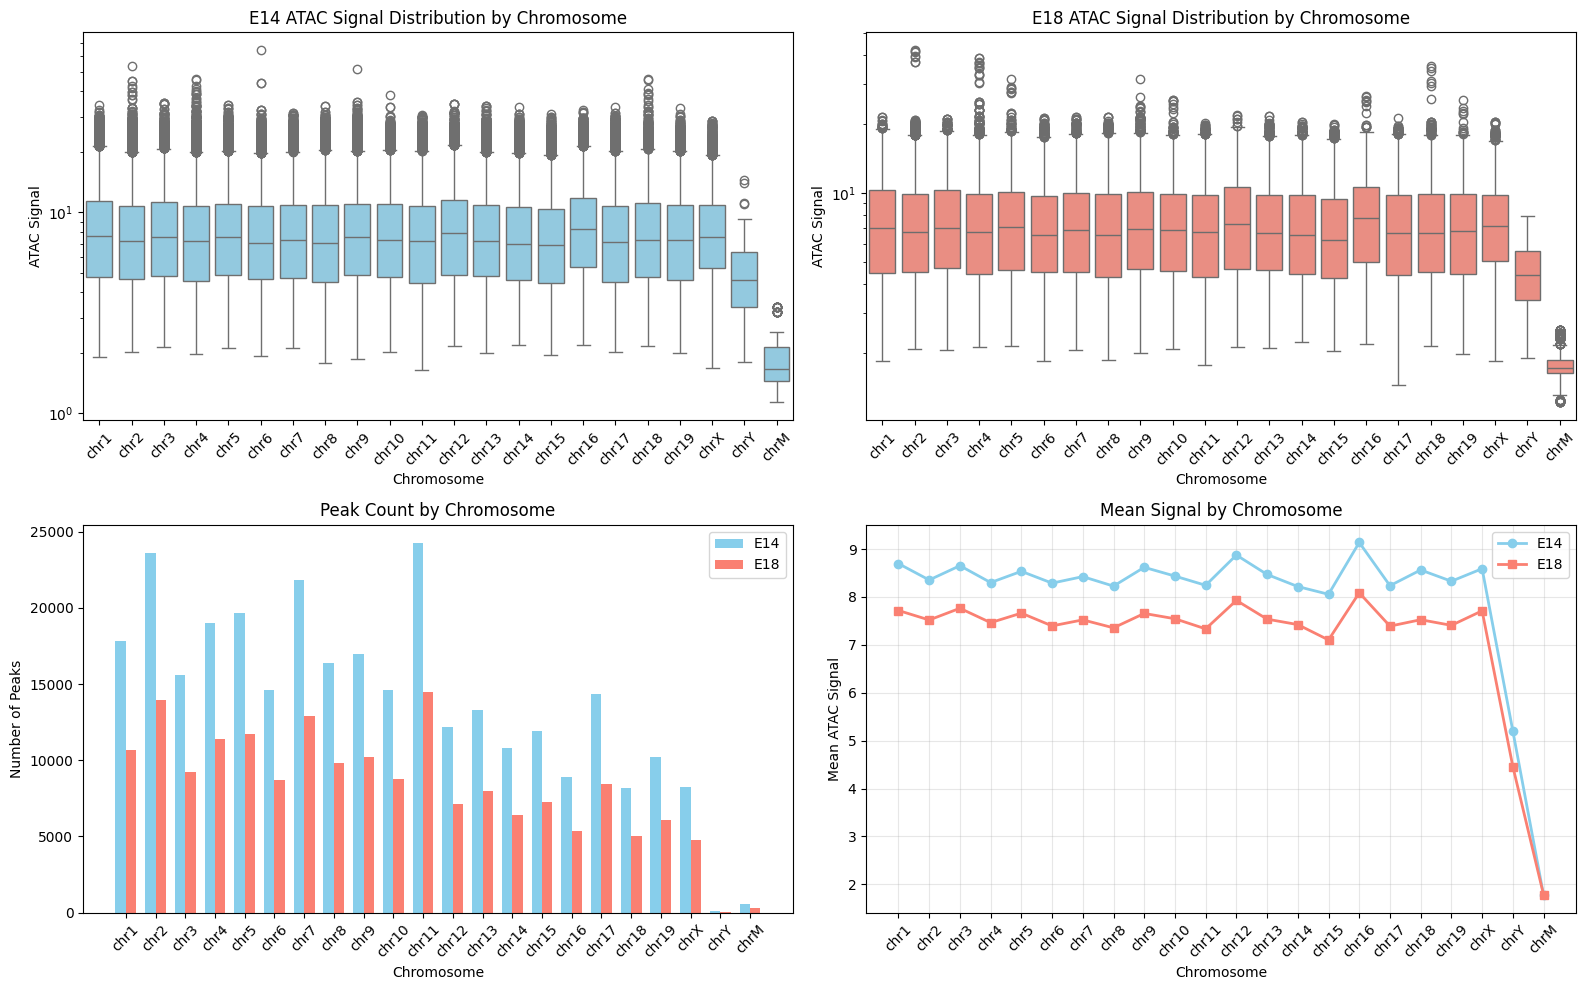


=== ATAC Signal Summary by Chromosome ===
                 count  mean  median   std
chr   condition                           
chr1  E14        17846  8.70    7.62  4.86
      E18        10707  7.72    7.03  3.76
chr10 E14        14647  8.44    7.30  4.62
      E18         8762  7.54    6.88  3.54
chr11 E14        24246  8.24    7.22  4.64
      E18        14472  7.33    6.76  3.52
chr12 E14        12162  8.88    7.89  4.88
      E18         7154  7.93    7.29  3.75
chr13 E14        13291  8.47    7.23  4.70
      E18         7995  7.54    6.68  3.58
chr14 E14        10837  8.22    6.99  4.65
      E18         6398  7.42    6.52  3.65
chr15 E14        11909  8.06    6.87  4.56
      E18         7267  7.10    6.21  3.50
chr16 E14         8934  9.14    8.26  4.78
      E18         5336  8.09    7.74  3.61
chr17 E14        14385  8.24    7.15  4.65
      E18         8445  7.39    6.71  3.52
chr18 E14         8165  8.56    7.26  4.92
      E18         5006  7.52    6.66  3.72
chr19 E14  

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
atac_df = nsc.atac_annotated.copy()
# Assuming your data is in a dataframe called 'atac_df'
# If not, load it first:
# atac_df = pd.read_csv('your_atac_file.csv')

def plot_atac_signal_by_chromosome(atac_df):
    """
    Plot ATAC-seq signal distribution by chromosome
    """
    
    # Extract chromosome order (chr1-19, chrX, chrY, chrM)
    chr_order = [f'chr{i}' for i in range(1, 20)] + ['chrX', 'chrY', 'chrM']
    chr_order = [c for c in chr_order if c in atac_df['chr'].unique()]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Signal distribution by chromosome (boxplot)
    ax1 = axes[0, 0]
    plot_data_e14 = atac_df[atac_df['condition'] == 'E14'].copy()
    plot_data_e14['chr'] = pd.Categorical(plot_data_e14['chr'], categories=chr_order, ordered=True)
    plot_data_e14 = plot_data_e14.sort_values('chr')
    
    sns.boxplot(data=plot_data_e14, x='chr', y='signalValue', ax=ax1, color='skyblue')
    ax1.set_xlabel('Chromosome')
    ax1.set_ylabel('ATAC Signal')
    ax1.set_title('E14 ATAC Signal Distribution by Chromosome')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_yscale('log')
    
    # 2. E18 signal distribution
    ax2 = axes[0, 1]
    plot_data_e18 = atac_df[atac_df['condition'] == 'E18'].copy()
    plot_data_e18['chr'] = pd.Categorical(plot_data_e18['chr'], categories=chr_order, ordered=True)
    plot_data_e18 = plot_data_e18.sort_values('chr')
    
    sns.boxplot(data=plot_data_e18, x='chr', y='signalValue', ax=ax2, color='salmon')
    ax2.set_xlabel('Chromosome')
    ax2.set_ylabel('ATAC Signal')
    ax2.set_title('E18 ATAC Signal Distribution by Chromosome')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_yscale('log')
    
    # 3. Number of peaks per chromosome
    ax3 = axes[1, 0]
    peak_counts = atac_df.groupby(['chr', 'condition']).size().reset_index(name='count')
    peak_counts['chr'] = pd.Categorical(peak_counts['chr'], categories=chr_order, ordered=True)
    peak_counts = peak_counts.sort_values('chr')
    
    e14_counts = peak_counts[peak_counts['condition'] == 'E14']
    e18_counts = peak_counts[peak_counts['condition'] == 'E18']
    
    x = np.arange(len(chr_order))
    width = 0.35
    
    ax3.bar(x - width/2, e14_counts['count'], width, label='E14', color='skyblue')
    ax3.bar(x + width/2, e18_counts['count'], width, label='E18', color='salmon')
    ax3.set_xlabel('Chromosome')
    ax3.set_ylabel('Number of Peaks')
    ax3.set_title('Peak Count by Chromosome')
    ax3.set_xticks(x)
    ax3.set_xticklabels(chr_order, rotation=45)
    ax3.legend()
    
    # 4. Mean signal per chromosome
    ax4 = axes[1, 1]
    mean_signal = atac_df.groupby(['chr', 'condition'])['signalValue'].mean().reset_index()
    mean_signal['chr'] = pd.Categorical(mean_signal['chr'], categories=chr_order, ordered=True)
    mean_signal = mean_signal.sort_values('chr')
    
    e14_mean = mean_signal[mean_signal['condition'] == 'E14']
    e18_mean = mean_signal[mean_signal['condition'] == 'E18']
    
    ax4.plot(e14_mean['chr'], e14_mean['signalValue'], marker='o', label='E14', color='skyblue', linewidth=2)
    ax4.plot(e18_mean['chr'], e18_mean['signalValue'], marker='s', label='E18', color='salmon', linewidth=2)
    ax4.set_xlabel('Chromosome')
    ax4.set_ylabel('Mean ATAC Signal')
    ax4.set_title('Mean Signal by Chromosome')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

# Use it
fig = plot_atac_signal_by_chromosome(atac_df)
# plt.savefig('atac_signal_by_chromosome.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Additional summary statistics
print("\n=== ATAC Signal Summary by Chromosome ===")
summary = atac_df.groupby(['chr', 'condition'])['signalValue'].agg(['count', 'mean', 'median', 'std']).round(2)
print(summary)

Loading E14 samples...
  ISF1045: 45576 peaks, signal range: 1.18-82.31
  ISF1048: 32779 peaks, signal range: 1.18-55.94
  ISF1052: 44614 peaks, signal range: 1.28-77.42
  ISF1053: 32094 peaks, signal range: 1.54-50.75
  ISF1057: 29610 peaks, signal range: 1.39-43.62
  ISF1059: 37325 peaks, signal range: 1.33-55.79
  ISF1063: 46418 peaks, signal range: 1.23-59.48

Loading E18 samples...
  ISF1049: 48904 peaks, signal range: 1.21-57.43
  ISF1050: 38260 peaks, signal range: 1.45-56.93
  ISF1055: 38294 peaks, signal range: 1.39-54.80
  ISF1056: 37467 peaks, signal range: 1.50-56.25
  ISF1060: 49535 peaks, signal range: 1.24-59.91
  ISF1061: 42881 peaks, signal range: 1.50-52.34
  ISF1065: 35743 peaks, signal range: 1.32-56.37
  ISF1066: 49987 peaks, signal range: 1.23-59.72

Total peaks: 609487
E14 peaks: 268416
E18 peaks: 341071

=== Summary Statistics ===

Signal Value:
              count      mean       std      min      25%      50%       75%  \
condition                             

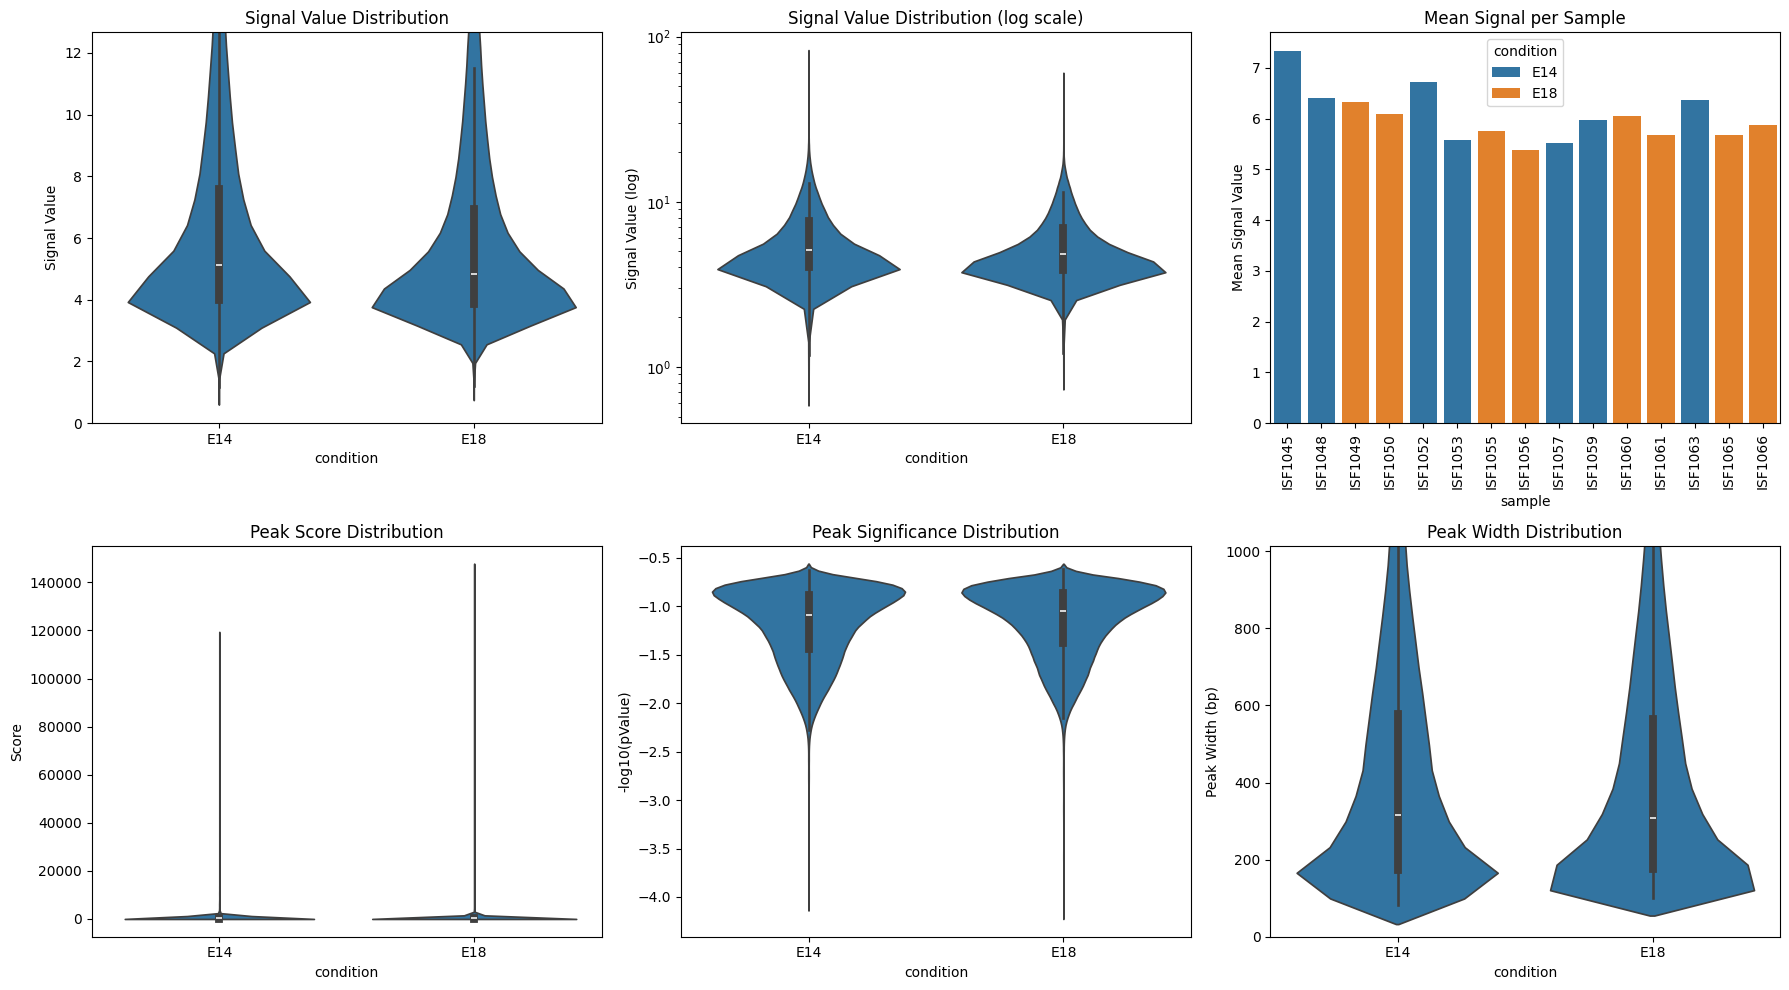

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob

def load_narrowpeak(file_path):
    """Load narrowPeak file"""
    cols = ['chr', 'start', 'end', 'name', 'score', 'strand', 
            'signalValue', 'pValue', 'qValue', 'peak']
    df = pd.read_csv(file_path, sep='\t', header=None, names=cols)
    return df

def visualize_narrowpeak_signals(peak_dir, samples_e14, samples_e18):
    """
    Minimal visualization of narrowPeak signal distributions
    """
    
    # Load all peaks
    all_data = []
    
    print("Loading E14 samples...")
    for sample in samples_e14:
        file_path = f"{peak_dir}/{sample}_peaks.narrowPeak"
        df = load_narrowpeak(file_path)
        df['sample'] = sample
        df['condition'] = 'E14'
        all_data.append(df)
        print(f"  {sample}: {len(df)} peaks, signal range: {df['signalValue'].min():.2f}-{df['signalValue'].max():.2f}")
    
    print("\nLoading E18 samples...")
    for sample in samples_e18:
        file_path = f"{peak_dir}/{sample}_peaks.narrowPeak"
        df = load_narrowpeak(file_path)
        df['sample'] = sample
        df['condition'] = 'E18'
        all_data.append(df)
        print(f"  {sample}: {len(df)} peaks, signal range: {df['signalValue'].min():.2f}-{df['signalValue'].max():.2f}")
    
    # Combine
    all_peaks = pd.concat(all_data, ignore_index=True)
    
    print(f"\nTotal peaks: {len(all_peaks)}")
    print(f"E14 peaks: {(all_peaks['condition']=='E14').sum()}")
    print(f"E18 peaks: {(all_peaks['condition']=='E18').sum()}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Signal distribution (violin plot)
    ax = axes[0, 0]
    sns.violinplot(data=all_peaks, x='condition', y='signalValue', ax=ax)
    ax.set_ylabel('Signal Value')
    ax.set_title('Signal Value Distribution')
    ax.set_ylim(0, all_peaks['signalValue'].quantile(0.95))
    
    # 2. Signal distribution (log scale)
    ax = axes[0, 1]
    sns.violinplot(data=all_peaks, x='condition', y='signalValue', ax=ax)
    ax.set_ylabel('Signal Value (log)')
    ax.set_title('Signal Value Distribution (log scale)')
    ax.set_yscale('log')
    
    # 3. Per-sample signal
    ax = axes[0, 2]
    sample_means = all_peaks.groupby(['sample', 'condition'])['signalValue'].mean().reset_index()
    sns.barplot(data=sample_means, x='sample', y='signalValue', hue='condition', ax=ax)
    ax.set_ylabel('Mean Signal Value')
    ax.set_title('Mean Signal per Sample')
    ax.tick_params(axis='x', rotation=90)
    
    # 4. Score distribution
    ax = axes[1, 0]
    sns.violinplot(data=all_peaks, x='condition', y='score', ax=ax)
    ax.set_ylabel('Score')
    ax.set_title('Peak Score Distribution')
    
    # 5. pValue distribution
    ax = axes[1, 1]
    all_peaks['log_pValue'] = -np.log10(all_peaks['pValue'] + 1e-300)
    sns.violinplot(data=all_peaks, x='condition', y='log_pValue', ax=ax)
    ax.set_ylabel('-log10(pValue)')
    ax.set_title('Peak Significance Distribution')
    
    # 6. Peak width distribution
    ax = axes[1, 2]
    all_peaks['width'] = all_peaks['end'] - all_peaks['start']
    sns.violinplot(data=all_peaks, x='condition', y='width', ax=ax)
    ax.set_ylabel('Peak Width (bp)')
    ax.set_title('Peak Width Distribution')
    ax.set_ylim(0, all_peaks['width'].quantile(0.95))
    
    plt.tight_layout()
    
    # Summary statistics
    print("\n=== Summary Statistics ===")
    print("\nSignal Value:")
    print(all_peaks.groupby('condition')['signalValue'].describe())
    
    print("\nScore:")
    print(all_peaks.groupby('condition')['score'].describe())
    
    print("\nPeak Width:")
    print(all_peaks.groupby('condition')['width'].describe())
    
    return fig, all_peaks


# Run it
peak_dir = '/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/data/atac_seq/ATAC-seq'

samples_e14 = ['ISF1045', 'ISF1048', 'ISF1052', 'ISF1053', 'ISF1057', 'ISF1059', 'ISF1063']
samples_e18 = ['ISF1049', 'ISF1050', 'ISF1055', 'ISF1056', 'ISF1060', 'ISF1061', 'ISF1065', 'ISF1066']

fig, all_peaks_df = visualize_narrowpeak_signals(peak_dir, samples_e14, samples_e18)
plt.savefig('narrowpeak_raw_signals.pdf', dpi=300, bbox_inches='tight')
plt.show()

Loading E14 Cortex samples...
  ISF1045: 45576 peaks
  ISF1053: 32094 peaks
  ISF1057: 29610 peaks

Loading E18 Cortex samples...
  ISF1049: 48904 peaks
  ISF1055: 38294 peaks
  ISF1056: 37467 peaks
  ISF1061: 42881 peaks
  ISF1066: 49987 peaks

=== Plotting chr1 ===
  ISF1045: 3318 peaks on chr1
  ISF1053: 2198 peaks on chr1
  ISF1057: 2107 peaks on chr1
  ISF1049: 3470 peaks on chr1
  ISF1055: 2771 peaks on chr1
  ISF1056: 2747 peaks on chr1
  ISF1061: 3088 peaks on chr1
  ISF1066: 3712 peaks on chr1


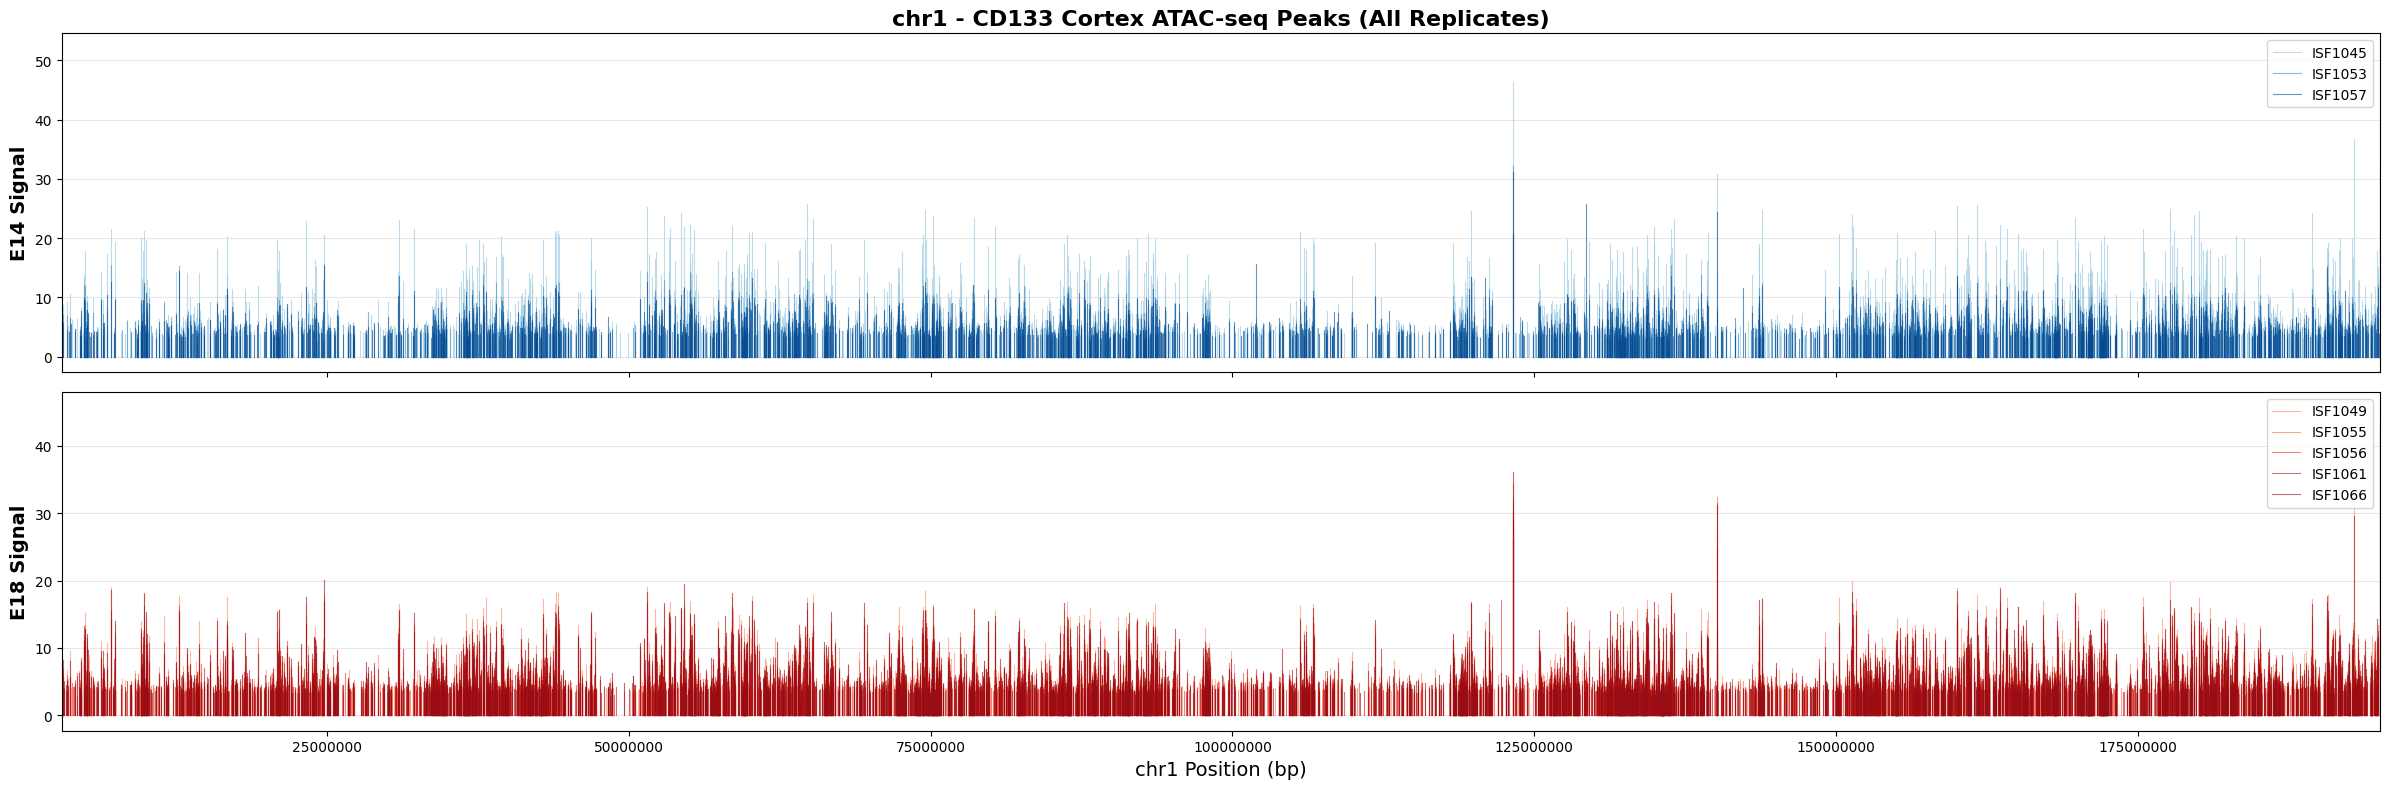


chr1 Statistics:

E14 samples:
  ISF1045: 3318 peaks, mean signal = 7.01, max signal = 51.95
  ISF1053: 2198 peaks, mean signal = 5.54, max signal = 39.55
  ISF1057: 2107 peaks, mean signal = 5.47, max signal = 32.16

E18 samples:
  ISF1049: 3470 peaks, mean signal = 6.17, max signal = 42.73
  ISF1055: 2771 peaks, mean signal = 5.58, max signal = 42.15
  ISF1056: 2747 peaks, mean signal = 5.27, max signal = 43.61
  ISF1061: 3088 peaks, mean signal = 5.46, max signal = 41.94
  ISF1066: 3712 peaks, mean signal = 5.71, max signal = 45.73

Overall chr1:
  E14: 7623 total peaks, mean signal = 6.16
  E18: 15788 total peaks, mean signal = 5.66

=== Plotting chr10 ===
  ISF1045: 2345 peaks on chr10
  ISF1053: 1663 peaks on chr10
  ISF1057: 1459 peaks on chr10


/tmp/ipykernel_586455/1633139743.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', fontsize=10)


  ISF1049: 2591 peaks on chr10
  ISF1055: 1972 peaks on chr10
  ISF1056: 2021 peaks on chr10
  ISF1061: 2252 peaks on chr10
  ISF1066: 2660 peaks on chr10


/tmp/ipykernel_586455/1633139743.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=10)


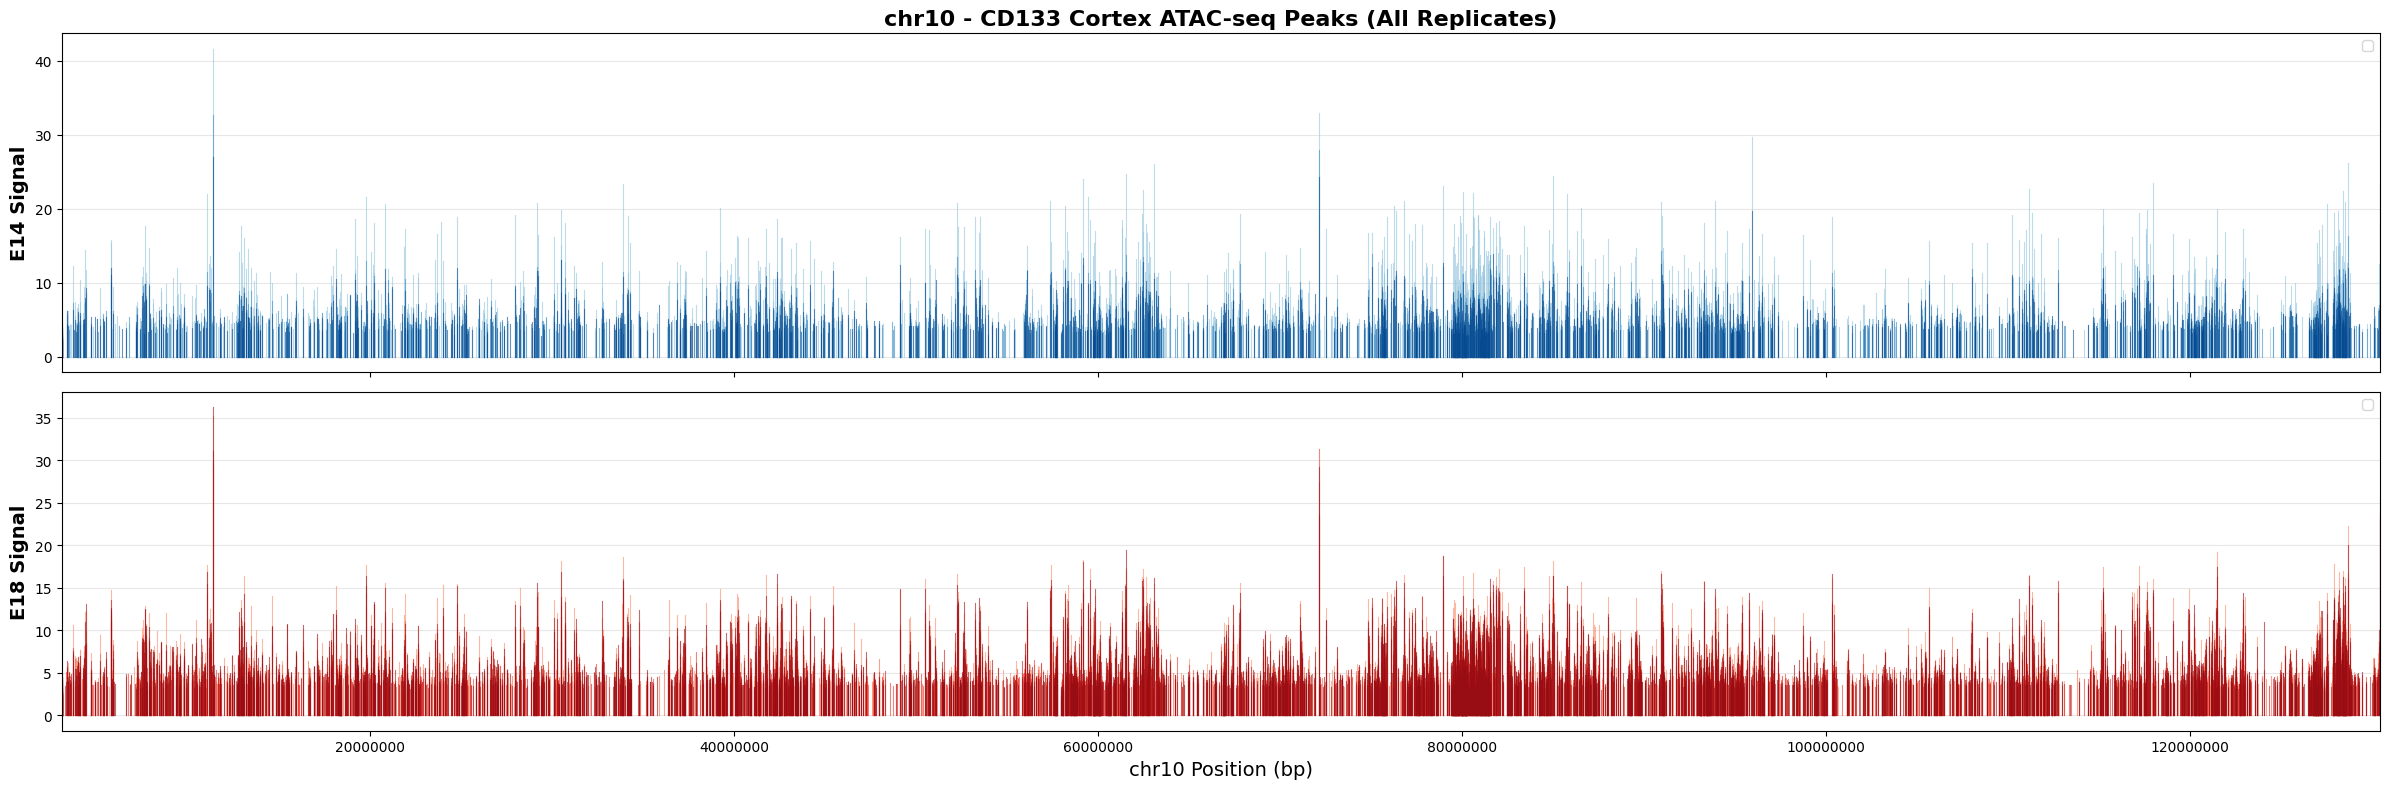


chr10 Statistics:

E14 samples:
  ISF1045: 2345 peaks, mean signal = 7.03, max signal = 41.62
  ISF1053: 1663 peaks, mean signal = 5.45, max signal = 32.66
  ISF1057: 1459 peaks, mean signal = 5.47, max signal = 26.95

E18 samples:
  ISF1049: 2591 peaks, mean signal = 6.17, max signal = 35.14
  ISF1055: 1972 peaks, mean signal = 5.63, max signal = 29.33
  ISF1056: 2021 peaks, mean signal = 5.21, max signal = 31.27
  ISF1061: 2252 peaks, mean signal = 5.53, max signal = 31.12
  ISF1066: 2660 peaks, mean signal = 5.70, max signal = 36.20

Overall chr10:
  E14: 5467 total peaks, mean signal = 6.13
  E18: 11496 total peaks, mean signal = 5.67


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_narrowpeak(file_path):
    """Load narrowPeak file"""
    cols = ['chr', 'start', 'end', 'name', 'score', 'strand', 
            'signalValue', 'pValue', 'qValue', 'peak']
    df = pd.read_csv(file_path, sep='\t', header=None, names=cols)
    return df

def plot_overlaid_peaks(peak_dir, samples_e14_cortex, samples_e18_cortex, chromosomes=['chr1', 'chr10']):
    """
    Overlay all CD133 Cortex samples on the same plot
    """
    
    # Load all samples
    print("Loading E14 Cortex samples...")
    e14_data = {}
    for sample in samples_e14_cortex:
        peaks = load_narrowpeak(f"{peak_dir}/{sample}_peaks.narrowPeak")
        e14_data[sample] = peaks
        print(f"  {sample}: {len(peaks)} peaks")
    
    print("\nLoading E18 Cortex samples...")
    e18_data = {}
    for sample in samples_e18_cortex:
        peaks = load_narrowpeak(f"{peak_dir}/{sample}_peaks.narrowPeak")
        e18_data[sample] = peaks
        print(f"  {sample}: {len(peaks)} peaks")
    
    # Plot each chromosome
    for chrom in chromosomes:
        print(f"\n=== Plotting {chrom} ===")
        
        # Get chromosome data from all samples
        e14_chr_all = {s: df[df['chr'] == chrom].sort_values('start') 
                       for s, df in e14_data.items()}
        e18_chr_all = {s: df[df['chr'] == chrom].sort_values('start') 
                       for s, df in e18_data.items()}
        
        # Determine x-axis limits (union of all peaks)
        all_starts = []
        all_ends = []
        for df in list(e14_chr_all.values()) + list(e18_chr_all.values()):
            if len(df) > 0:
                all_starts.append(df['start'].min())
                all_ends.append(df['end'].max())
        
        if len(all_starts) == 0:
            print(f"  No peaks on {chrom}, skipping")
            continue
        
        xlim = (min(all_starts), max(all_ends))
        
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 8), sharex=True)
        
        # Colors for replicates
        e14_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(samples_e14_cortex)))
        e18_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(samples_e18_cortex)))
        
        # Plot E14 samples (overlaid)
        for idx, (sample, df) in enumerate(e14_chr_all.items()):
            print(f"  {sample}: {len(df)} peaks on {chrom}")
            for _, row in df.iterrows():
                center = (row['start'] + row['end']) / 2
                ax1.plot([center, center], [0, row['signalValue']], 
                        color=e14_colors[idx], linewidth=0.8, alpha=0.6, 
                        label=sample if _ == 0 else "")
        
        ax1.set_ylabel('E14 Signal', fontsize=14, fontweight='bold')
        ax1.set_title(f'{chrom} - CD133 Cortex ATAC-seq Peaks (All Replicates)', 
                     fontsize=16, fontweight='bold')
        ax1.legend(loc='upper right', fontsize=10)
        ax1.grid(axis='y', alpha=0.3)
        ax1.set_xlim(xlim)
        
        # Plot E18 samples (overlaid)
        for idx, (sample, df) in enumerate(e18_chr_all.items()):
            print(f"  {sample}: {len(df)} peaks on {chrom}")
            for _, row in df.iterrows():
                center = (row['start'] + row['end']) / 2
                ax2.plot([center, center], [0, row['signalValue']], 
                        color=e18_colors[idx], linewidth=0.8, alpha=0.6,
                        label=sample if _ == 0 else "")
        
        ax2.set_ylabel('E18 Signal', fontsize=14, fontweight='bold')
        ax2.set_xlabel(f'{chrom} Position (bp)', fontsize=14)
        ax2.legend(loc='upper right', fontsize=10)
        ax2.grid(axis='y', alpha=0.3)
        ax2.set_xlim(xlim)
        
        # Format x-axis
        ax2.ticklabel_format(style='plain', axis='x')
        
        plt.tight_layout()
        plt.savefig(f'overlaid_peaks_{chrom}_cortex_cd133.pdf', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Statistics per chromosome
        print(f"\n{chrom} Statistics:")
        print("\nE14 samples:")
        for sample, df in e14_chr_all.items():
            if len(df) > 0:
                print(f"  {sample}: {len(df)} peaks, mean signal = {df['signalValue'].mean():.2f}, "
                      f"max signal = {df['signalValue'].max():.2f}")
        
        print("\nE18 samples:")
        for sample, df in e18_chr_all.items():
            if len(df) > 0:
                print(f"  {sample}: {len(df)} peaks, mean signal = {df['signalValue'].mean():.2f}, "
                      f"max signal = {df['signalValue'].max():.2f}")
        
        # Overall stats
        e14_all_peaks = pd.concat(e14_chr_all.values())
        e18_all_peaks = pd.concat(e18_chr_all.values())
        
        print(f"\nOverall {chrom}:")
        print(f"  E14: {len(e14_all_peaks)} total peaks, mean signal = {e14_all_peaks['signalValue'].mean():.2f}")
        print(f"  E18: {len(e18_all_peaks)} total peaks, mean signal = {e18_all_peaks['signalValue'].mean():.2f}")


# Define Cortex CD133 samples
peak_dir = '/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/data/atac_seq/ATAC-seq'

# CD133 Cortex samples only
e14_cortex = ['ISF1045', 'ISF1053', 'ISF1057']  # E14 Cortex CD133
e18_cortex = ['ISF1049', 'ISF1055', 'ISF1056', 'ISF1061', 'ISF1066']  # E18 Cortex CD133

plot_overlaid_peaks(peak_dir, e14_cortex, e18_cortex, chromosomes=['chr1', 'chr10'])

## Exploring functional genes only

In [19]:
import pandas as pd

# Load SynGO data
syngo_dir = '/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/data/synGO'

syngo_annotations = pd.read_excel(f'{syngo_dir}/syngo_annotations.xlsx')
syngo_genes = pd.read_excel(f'{syngo_dir}/syngo_genes.xlsx')
syngo_ontologies = pd.read_excel(f'{syngo_dir}/syngo_ontologies.xlsx')

print("="*80)
print("SYNGO DATA STRUCTURE")
print("="*80)

print("\n1. SYNGO GENES")
print(f"   Shape: {syngo_genes.shape}")
print(f"   Columns: {syngo_genes.columns.tolist()}")
print("\nFirst 10 rows:")
print(syngo_genes.head(10))

# Extract gene list from SynGO (uppercase)
if 'hgnc_symbol' in syngo_genes.columns:
    syngo_gene_list = set(syngo_genes['hgnc_symbol'].str.upper().dropna().unique())
elif 'gene_symbol' in syngo_genes.columns:
    syngo_gene_list = set(syngo_genes['gene_symbol'].str.upper().dropna().unique())
elif 'symbol' in syngo_genes.columns:
    syngo_gene_list = set(syngo_genes['symbol'].str.upper().dropna().unique())
else:
    print("Available columns with 'gene' or 'symbol':")
    print([col for col in syngo_genes.columns if 'gene' in col.lower() or 'symbol' in col.lower()])
    syngo_gene_list = set()

print(f"\nTotal genes in SynGO: {len(syngo_gene_list)}")
print(f"Example SynGO genes: {list(syngo_gene_list)[:10]}")

# Get our DE genes (UPPERCASE)
deg_list_e14_non_tf = deseq_results[
    (deseq_results['log2FoldChange'] > 1) & 
    (deseq_results['padj'] < 0.05) & 
    (~deseq_results['is_TF'])
]['symbol'].str.upper().tolist()

deg_list_e18_non_tf = deseq_results[
    (deseq_results['log2FoldChange'] < -1) & 
    (deseq_results['padj'] < 0.05) & 
    (~deseq_results['is_TF'])
]['symbol'].str.upper().tolist()

print(f"\nOur E14-high non-TF genes: {len(deg_list_e14_non_tf)}")
print(f"Our E18-high non-TF genes: {len(deg_list_e18_non_tf)}")

# Check overlap
e14_in_syngo = set(deg_list_e14_non_tf) & syngo_gene_list
e18_in_syngo = set(deg_list_e18_non_tf) & syngo_gene_list

print("\n" + "="*80)
print("OVERLAP WITH SYNGO")
print("="*80)

print(f"\nE14-high genes in SynGO: {len(e14_in_syngo)} ({100*len(e14_in_syngo)/len(deg_list_e14_non_tf):.1f}%)")
print(f"E18-high genes in SynGO: {len(e18_in_syngo)} ({100*len(e18_in_syngo)/len(deg_list_e18_non_tf):.1f}%)")

print("\nE14-high genes in SynGO (first 30):")
print(sorted(list(e14_in_syngo))[:30])

print("\nE18-high genes in SynGO (first 30):")
print(sorted(list(e18_in_syngo))[:30])

SYNGO DATA STRUCTURE

1. SYNGO GENES
   Shape: (1602, 6)
   Columns: ['hgnc_id', 'hgnc_symbol', 'hgnc_synonyms', 'hgnc_name', 'ensembl_id', 'entrez_id']

First 10 rows:
      hgnc_id hgnc_symbol                                  hgnc_synonyms  \
0  HGNC:19679        AAK1                       KIAA1048, DKFZP686K16132   
1     HGNC:59       ABCC8     PHHI, SUR1, ABC36, HHF1, TNDM2, SUR, HRINS   
2  HGNC:28756     ABHD17A                    MGC5244, C19ORF27, FAM108A1   
3  HGNC:24278     ABHD17B                      CGI-67, C9ORF77, FAM108B1   
4  HGNC:26925     ABHD17C                                       FAM108C1   
5  HGNC:21398       ABHD6                                            NaN   
6  HGNC:11320        ABI1                           E3B1, ABI-1, SSH3BP1   
7  HGNC:24011        ABI2  ABI-2, AIP-1, ABI2B, ABLBP3, ARGBPIA, SSH3BP2   
8  HGNC:29859        ABI3                                  NESH, SSH3BP3   
9     HGNC:76        ABL1                                    JTK7, C-AB

In [21]:
len(e14_in_syngo)/len(deg_list_e14_non_tf)

0.10648148148148148

In [22]:
len(e18_in_syngo)/len(deg_list_e18_non_tf)

0.10057024364955935

## Defining master regulator scoring for prioritizing 

### Input Data:

1. DE Results (RNA-seq) - deseq_results DataFrame

    `Columns: symbol, log2FoldChange, padj, is_TF, baseMean
    E14-high genes: log2FC > 1, padj < 0.05
    E18-high genes: log2FC < -1, padj < 0.05`


2. ChIP-seq Network - chip_edges DataFrame

    `Columns: TF, Target
    TF → Target gene relationships
    `

3. Enhancer Database - enhancer_db_with_atac DataFrame

    `Columns: chr, start, end, symbol, score, enhancer_id, region_class
    Enhancer → Gene links with coordinates
    `

4. DA Peaks (ATAC-seq) - dar_all or dar_cortex DataFrame

    `Columns: seqnames, start, end, Fold, FDR
    E14-enriched: Fold > 0
    E18-enriched: Fold < 0
    `

5. SynGO Functional Genes - syngo_genes DataFrame

    `Columns: gene symbols (human, uppercase)
    Filters DE genes to functionally relevant synaptic genes
    `

6. SynGO Annotations - syngo_annotations DataFrame

    `Links genes to GO terms/pathways
    For functional classification`

### OUTPUT DATA:

1. E14 Master Regulators - DataFrame

`Columns: TF, log2FC, padj, n_targets, n_functional_targets, target_consistency, chromatin_accessibility, MR_score`


2. E18 Master Regulators - DataFrame

`Same structure as above`


3. TF-Target-Enhancer Links - DataFrame

`Columns: TF, target_gene, enhancer_id, has_DA_peak, functional
Detailed evidence for each TF-target pair`

### Probability calculation
Instead of arbitrary weights, we use **softmax** to calculate the probability that each TF is a master regulator relative to all other candidate TFs.

### Formula:
```python
# For each TF:
raw_score_i = expression_normalized + target_consistency + chromatin_accessibility

# Softmax probability:
P(TF_i is master regulator) = exp(raw_score_i / T) / Σ exp(raw_score_j / T)
```

### Interpretation:
- **P(MR) = 0.15**: TF has 15% probability of being a master regulator (among all candidates)
- Higher values = stronger multi-layer evidence
- Probabilities sum to 1.0 across all TFs

### Temperature Parameter (T):
- **T = 0.5**: Stringent (only top TFs get high probability)
- **T = 1.0**: Balanced (default)
- **T = 2.0**: Permissive (more TFs get moderate probability)

### Example Output:
```
TF       | log2FC | Target_Consistency | Chromatin_Access | MR_Probability | Rank
---------|--------|-------------------|------------------|----------------|------
Neurod1  | 3.2    | 0.73              | 0.68             | 0.18           | 1
Pax6     | 2.8    | 0.71              | 0.65             | 0.14           | 2
Eomes    | 2.5    | 0.68              | 0.62             | 0.11           | 3
```

In [26]:
enhancers_mm39

,chr,start,end,symbol,score
0,chr1,131450871,131452671,Srgap2,7.628647
1,chr19,46304509,46307909,Nfkb2,7.628647
2,chr5,8416740,8417200,Adam22,7.556866
3,chr1,166082028,166088968,Ildr2,7.504045
4,chr12,86994024,86994114,6430527G18Rik,7.442114
...,...,...,...,...,...
124007,chr7,45293494,45293624,Lmtk3,0.000319
124008,chr19,4560608,4561748,Ppp1ca,0.000225
124009,chr12,72282307,72282427,2810055F11Rik,0.000069
124010,chr7,44667584,44668214,Dkkl1,0.000043


In [27]:
import pandas as pd
import numpy as np

# ==============================================================================
# LOAD ALL INPUT DATA FOR MASTER REGULATOR ANALYSIS
# ==============================================================================

print("="*80)
print("LOADING INPUT DATA")
print("="*80)

# Paths
base_dir = '/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC'
syngo_dir = f'{base_dir}/data/synGO'
results_dir = f'{base_dir}/results/cd133_e14_e18_grn'
diffbind_dir = f'{base_dir}/results/diffbind_cd133'

# ==============================================================================
# 1. DESEQ RESULTS (RNA-seq) - Already loaded
# ==============================================================================
print("\n[1/7] DESeq results...")
# Assuming you already have this as 'deseq_results'
# If not:
# deseq_results = pd.read_csv(f'{results_dir}/deseq_temporal_cd133.csv')

print(f"  ✓ DE genes: {len(deseq_results)}")
print(f"  ✓ DE TFs: {deseq_results['is_TF'].sum()}")

# ==============================================================================
# 2. CHIP-SEQ NETWORK (TF → Target edges)
# ==============================================================================
print("\n[2/7] Loading ChIP-seq network...")

chip_path = f'{base_dir}/data/chip_seq/mouse_all_chip.csv'
chip_network = pd.read_csv(chip_path)

# Create edges DataFrame
chip_edges = chip_network[['TF', 'Target']].copy()

# Convert to title case for mouse genes
chip_edges['TF'] = chip_edges['TF'].str.title()
chip_edges['Target'] = chip_edges['Target'].str.title()

print(f"  ✓ Total TF-target edges: {len(chip_edges):,}")
print(f"  ✓ Unique TFs: {chip_edges['TF'].nunique()}")
print(f"  ✓ Unique targets: {chip_edges['Target'].nunique()}")

# ==============================================================================
# 3. ENHANCER DATABASE - Already loaded
# ==============================================================================
print("\n[3/7] Enhancer database...")
# Assuming you already have this as 'enhancers_mm39' or similar
# enhancer_db = enhancers_mm39.copy()
enhancer_db = enhancers_mm39.copy()
print(f"  ✓ Total enhancer-gene links: {len(enhancer_db):,}")
# print(f"  ✓ Unique enhancers: {enhancer_db['enhancer_id'].nunique():,}")
print(f"  ✓ Genes with enhancers: {enhancer_db['symbol'].nunique():,}")

# ==============================================================================
# 4. DIFFERENTIAL ATAC PEAKS (DiffBind results)
# ==============================================================================
print("\n[4/7] Loading differential ATAC peaks...")

# Load both datasets
dar_all = pd.read_csv(f'{diffbind_dir}/DAR_cd133_all_tissues_sig.csv')
dar_cortex = pd.read_csv(f'{diffbind_dir}/DAR_cd133_cortex_sig.csv')

print(f"  ✓ All CD133 DA peaks: {len(dar_all)}")
print(f"    - E14-enriched: {(dar_all['Fold'] > 0).sum()}")
print(f"    - E18-enriched: {(dar_all['Fold'] < 0).sum()}")

print(f"  ✓ Cortex CD133 DA peaks: {len(dar_cortex)}")
print(f"    - E14-enriched: {(dar_cortex['Fold'] > 0).sum()}")
print(f"    - E18-enriched: {(dar_cortex['Fold'] < 0).sum()}")

# ==============================================================================
# 5. SYNGO GENES (Functional synaptic genes)
# ==============================================================================
print("\n[5/7] Loading SynGO genes...")

syngo_genes = pd.read_excel(f'{syngo_dir}/syngo_genes.xlsx')

print(f"  ✓ SynGO genes loaded: {len(syngo_genes)}")
print(f"  Columns: {syngo_genes.columns.tolist()}")

# Show first few rows to understand structure
print("\n  First 5 rows:")
print(syngo_genes.head())

# Extract gene symbols (check which column has the gene names)
if 'hgnc_symbol' in syngo_genes.columns:
    syngo_gene_col = 'hgnc_symbol'
elif 'gene_symbol' in syngo_genes.columns:
    syngo_gene_col = 'gene_symbol'
elif 'symbol' in syngo_genes.columns:
    syngo_gene_col = 'symbol'
else:
    # Use first column
    syngo_gene_col = syngo_genes.columns[0]
    print(f"  Using column: {syngo_gene_col}")

syngo_gene_list = set(syngo_genes[syngo_gene_col].str.upper().dropna().unique())
print(f"  ✓ Unique functional genes: {len(syngo_gene_list)}")

# ==============================================================================
# 6. SYNGO ANNOTATIONS (Gene functional categories)
# ==============================================================================
print("\n[6/7] Loading SynGO annotations...")

syngo_annotations = pd.read_excel(f'{syngo_dir}/syngo_annotations.xlsx')

print(f"  ✓ SynGO annotations loaded: {len(syngo_annotations)}")
print(f"  Columns: {syngo_annotations.columns.tolist()}")

# Show first few rows
print("\n  First 5 rows:")
print(syngo_annotations.head())

# ==============================================================================
# 7. SYNGO ONTOLOGIES (GO terms)
# ==============================================================================
print("\n[7/7] Loading SynGO ontologies...")

syngo_ontologies = pd.read_excel(f'{syngo_dir}/syngo_ontologies.xlsx')

print(f"  ✓ SynGO ontologies loaded: {len(syngo_ontologies)}")
print(f"  Columns: {syngo_ontologies.columns.tolist()}")

# Check for neurogenesis vs gliogenesis terms
if 'name' in syngo_ontologies.columns:
    neuro_terms = syngo_ontologies[
        syngo_ontologies['name'].str.contains('neuro|axon|dendrite|synap', case=False, na=False)
    ]
    print(f"\n  Neuronal/synaptic terms: {len(neuro_terms)}")
    
    glia_terms = syngo_ontologies[
        syngo_ontologies['name'].str.contains('glia|astro|oligo|myelin', case=False, na=False)
    ]
    print(f"  Glial terms: {len(glia_terms)}")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("DATA LOADING COMPLETE")
print("="*80)

print("\nAll required inputs ready:")
print(f"  ✓ deseq_results: {len(deseq_results):,} genes")
print(f"  ✓ chip_edges: {len(chip_edges):,} TF-target pairs")
print(f"  ✓ enhancer_db: {len(enhancer_db):,} enhancer-gene links")
print(f"  ✓ dar_all: {len(dar_all)} DA peaks")
print(f"  ✓ dar_cortex: {len(dar_cortex)} DA peaks")
print(f"  ✓ syngo_genes: {len(syngo_gene_list)} functional genes")
print(f"  ✓ syngo_annotations: {len(syngo_annotations)} annotations")
print(f"  ✓ syngo_ontologies: {len(syngo_ontologies)} ontology terms")

print("\nReady to run MasterRegulatorAnalysis!")

LOADING INPUT DATA

[1/7] DESeq results...
  ✓ DE genes: 18187
  ✓ DE TFs: 1190

[2/7] Loading ChIP-seq network...
  ✓ Total TF-target edges: 6,946,884
  ✓ Unique TFs: 1780
  ✓ Unique targets: 39769

[3/7] Enhancer database...
  ✓ Total enhancer-gene links: 124,012
  ✓ Genes with enhancers: 16,616

[4/7] Loading differential ATAC peaks...
  ✓ All CD133 DA peaks: 1940
    - E14-enriched: 1680
    - E18-enriched: 260
  ✓ Cortex CD133 DA peaks: 2242
    - E14-enriched: 1733
    - E18-enriched: 509

[5/7] Loading SynGO genes...
  ✓ SynGO genes loaded: 1602
  Columns: ['hgnc_id', 'hgnc_symbol', 'hgnc_synonyms', 'hgnc_name', 'ensembl_id', 'entrez_id']

  First 5 rows:
      hgnc_id hgnc_symbol                               hgnc_synonyms  \
0  HGNC:19679        AAK1                    KIAA1048, DKFZP686K16132   
1     HGNC:59       ABCC8  PHHI, SUR1, ABC36, HHF1, TNDM2, SUR, HRINS   
2  HGNC:28756     ABHD17A                 MGC5244, C19ORF27, FAM108A1   
3  HGNC:24278     ABHD17B            

In [74]:
dar_cortex 

,seqnames,start,end,width,strand,Conc,Conc_E18,Conc_E14,Fold,p.value,...,ISF1055,ISF1056,ISF1061,ISF1066,ISF1045,ISF1046,ISF1047,ISF1051,ISF1053,ISF1057
0,chr2,61363381,61363881,501,*,6.231043,7.166422,4.170179,2.711309,1.063384e-31,...,148.40,110.05,124.37,138.86,27.06,13.86,10.16,19.49,11.70,25.75
1,chr8,93576797,93577297,501,*,6.271383,7.020766,5.061952,1.841610,2.423641e-27,...,131.79,97.28,145.93,130.12,30.93,39.59,28.46,31.80,31.59,38.06
2,chr1,89328288,89328788,501,*,6.401690,7.295364,4.591138,2.435160,1.169178e-25,...,154.63,94.33,136.80,157.20,33.83,22.76,16.26,22.57,24.57,24.63
3,chr4,119931199,119931699,501,*,6.050221,6.780522,4.900927,1.760680,3.684756e-25,...,99.62,96.29,114.42,108.29,36.73,28.70,22.36,30.78,31.59,29.10
4,chr8,127634095,127634595,501,*,5.854697,6.667203,4.419454,2.064329,2.060029e-24,...,107.93,73.69,84.57,106.54,24.16,17.82,23.37,19.49,23.40,20.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2237,chr7,76974938,76975438,501,*,4.044691,2.764458,4.620222,-1.006844,7.742831e-04,...,4.15,7.86,5.80,9.61,8.70,24.74,60.98,34.88,8.19,10.07
2238,chr14,77716080,77716580,501,*,4.275549,2.815933,4.889403,-1.009913,7.785641e-04,...,7.26,7.86,8.29,5.24,5.80,41.57,32.52,82.07,4.68,11.19
2239,chr6,127582238,127582738,501,*,5.302802,3.909830,5.903088,-1.009816,7.826332e-04,...,10.38,16.70,15.75,19.21,25.13,89.08,77.24,134.38,17.55,15.67
2240,chr9,25289272,25289772,501,*,6.842203,7.569750,5.701320,1.005400,7.893896e-04,...,173.31,113.98,165.82,209.59,106.32,18.81,28.46,10.26,65.52,82.83


## Checking overlap of enhancers with atac data

In [132]:
import pandas as pd
import pybedtools

# Load data
dar_e14 = dar_cortex[dar_cortex['Fold'] > 0].copy()
dar_e18 = dar_cortex[dar_cortex['Fold'] < 0].copy()

print(f"E14-enriched DA peaks: {len(dar_e14)}")
print(f"E18-enriched DA peaks: {len(dar_e18)}")

# Check enhancer DB
print(f"\nEnhancer DB shape: {enhancer_db.shape}")
print(f"Enhancer DB columns: {enhancer_db.columns.tolist()}")
print(f"\nFirst 3 enhancers:")
print(enhancer_db[['chr', 'start', 'end', 'symbol']].head(3))

# Create BED objects
print("\n=== Testing E14 overlap ===")
dar_e14_bed = pybedtools.BedTool.from_dataframe(
    dar_e14[['seqnames', 'start', 'end']].rename(columns={'seqnames': 'chrom'})
)

enhancer_bed = pybedtools.BedTool.from_dataframe(
    enhancer_db[['chr', 'start', 'end', 'symbol']].rename(columns={'chr': 'chrom', 'symbol': 'name'})
)

# Overlap: enhancers that overlap DA peaks
overlaps_e14 = enhancer_bed.intersect(dar_e14_bed, wa=True, u=True)

# Extract genes
genes_e14 = set()
for interval in overlaps_e14:
    print(f"Interval: {interval}")  # Show first few
    print(f"  Fields: {interval.fields}")
    print(f"  Name attr: {interval.name if hasattr(interval, 'name') else 'NO NAME'}")
    gene = interval.fields[3] if len(interval.fields) > 3 else None
    if gene:
        genes_e14.add(gene.upper())
    
    if len(genes_e14) > 5:  # Just show first few
        break

print(f"\nE14 accessible genes (first 20): {sorted(list(genes_e14))[:20]}")

# Same for E18
print("\n=== Testing E18 overlap ===")
dar_e18_bed = pybedtools.BedTool.from_dataframe(
    dar_e18[['seqnames', 'start', 'end']].rename(columns={'seqnames': 'chrom'})
)

overlaps_e18 = enhancer_bed.intersect(dar_e18_bed, wa=True, u=True)

genes_e18 = set()
for interval in overlaps_e18:
    gene = interval.fields[3] if len(interval.fields) > 3 else None
    if gene:
        genes_e18.add(gene.upper())

print(f"\nE18 accessible genes (first 20): {sorted(list(genes_e18))[:20]}")
print(f"\nTotal E14 accessible: {len(genes_e14)}")
print(f"Total E18 accessible: {len(genes_e18)}")

E14-enriched DA peaks: 1733
E18-enriched DA peaks: 509

Enhancer DB shape: (124012, 5)
Enhancer DB columns: ['chr', 'start', 'end', 'symbol', 'score']

First 3 enhancers:
     chr      start        end  symbol
0   chr1  131450871  131452671  Srgap2
1  chr19   46304509   46307909   Nfkb2
2   chr5    8416740    8417200  Adam22

=== Testing E14 overlap ===
Interval: chr14	67084462	67087052	Dpysl2

  Fields: ['chr14', '67084462', '67087052', 'Dpysl2']
  Name attr: Dpysl2
Interval: chr11	78042784	78044514	Tlcd1

  Fields: ['chr11', '78042784', '78044514', 'Tlcd1']
  Name attr: Tlcd1
Interval: chr18	37955179	37958069	Rell2

  Fields: ['chr18', '37955179', '37958069', 'Rell2']
  Name attr: Rell2
Interval: chr6	83385578	83388578	Tet3

  Fields: ['chr6', '83385578', '83388578', 'Tet3']
  Name attr: Tet3
Interval: chr11	78042784	78044514	Traf4

  Fields: ['chr11', '78042784', '78044514', 'Traf4']
  Name attr: Traf4
Interval: chr14	67084462	67087052	Gm5464

  Fields: ['chr14', '67084462', '670870

In [134]:
# Check coordinate ranges
print("=== E14 DA Peak coordinate ranges ===")
print(f"Min start: {dar_e14['start'].min()}")
print(f"Max start: {dar_e14['start'].max()}")
print(f"Min end: {dar_e14['end'].min()}")
print(f"Max end: {dar_e14['end'].max()}")

print("\n=== Enhancer coordinate ranges (chr2 only) ===")
enh_chr2 = enhancer_db[enhancer_db['chr'] == 'chr2']
print(f"Min start: {enh_chr2['start'].min()}")
print(f"Max start: {enh_chr2['start'].max()}")
print(f"Min end: {enh_chr2['end'].min()}")
print(f"Max end: {enh_chr2['end'].max()}")

print("\n=== Sample enhancers on chr2 ===")
print(enh_chr2[['chr', 'start', 'end', 'symbol']].head(10))

print("\n=== Sample E14 DA peaks on chr2 ===")
dar_e14_chr2 = dar_e14[dar_e14['seqnames'] == 'chr2']
print(dar_e14_chr2[['seqnames', 'start', 'end', 'Fold']].head(10))

# Check for ANY overlap between the two datasets on chr2
print(f"\n=== Testing ANY overlap on chr2 ===")
print(f"E14 peaks on chr2: {len(dar_e14_chr2)}")
print(f"Enhancers on chr2: {len(enh_chr2)}")

# Try bedtools directly
dar_chr2_bed = pybedtools.BedTool.from_dataframe(
    dar_e14_chr2[['seqnames', 'start', 'end']].rename(columns={'seqnames': 'chrom'}).head(100)
)
enh_chr2_bed = pybedtools.BedTool.from_dataframe(
    enh_chr2[['chr', 'start', 'end', 'symbol']].rename(columns={'chr': 'chrom', 'symbol': 'name'}).head(1000)
)

overlaps_chr2 = dar_chr2_bed.intersect(enh_chr2_bed, wa=True, wb=True)
print(f"Bedtools overlaps on chr2 (first 100 peaks vs first 1000 enhancers): {overlaps_chr2.count()}")

=== E14 DA Peak coordinate ranges ===
Min start: 3268726
Max start: 194311464
Min end: 3269226
Max end: 194311964

=== Enhancer coordinate ranges (chr2 only) ===
Min start: 3119685
Max start: 181654247
Min end: 3121135
Max end: 181655187

=== Sample enhancers on chr2 ===
      chr      start        end   symbol
32   chr2  180343148  180343748    Dido1
65   chr2   22959292   22959462    Acbd5
70   chr2  121244685  121244755  Gm14001
81   chr2   15059214   15059474    Arl5b
82   chr2  167344500  167345350   Rnf114
83   chr2  167345520  167347920   Rnf114
86   chr2   72810167   72810587      Sp3
104  chr2   32202352   32202692     Dnm1
112  chr2   25224502   25225592    Ssna1
114  chr2  129447594  129449554    Sirpa

=== Sample E14 DA peaks on chr2 ===
    seqnames      start        end      Fold
0       chr2   61363381   61363881  2.711309
5       chr2    4041494    4041994  2.200758
25      chr2   17842305   17842805  1.746327
67      chr2  162233734  162234234  1.791387
110     chr2  1

In [135]:
# Check enhancer size distribution
enhancer_db['size'] = enhancer_db['end'] - enhancer_db['start']
print("=== Enhancer size distribution ===")
print(enhancer_db['size'].describe())

# Check DA peak size
dar_e14['size'] = dar_e14['end'] - dar_e14['start']
print("\n=== E14 DA peak size distribution ===")
print(dar_e14['size'].describe())

# Calculate total genomic coverage
enh_total_bp = enhancer_db['size'].sum()
dar_e14_total_bp = dar_e14['size'].sum()
chr2_length = 182e6  # approximate mouse chr2 length

print(f"\n=== Genomic coverage ===")
print(f"Enhancers cover: {enh_total_bp:,} bp ({100*enh_total_bp/3e9:.2f}% of genome)")
print(f"E14 DA peaks cover: {dar_e14_total_bp:,} bp ({100*dar_e14_total_bp/3e9:.2f}% of genome)")

# Check distance from nearest DA peak to nearest enhancer
print("\n=== Checking nearest distances ===")
dar_e14_chr2 = dar_e14[dar_e14['seqnames'] == 'chr2'].copy()
enh_chr2 = enhancer_db[enhancer_db['chr'] == 'chr2'].copy()

# Pick one DA peak
peak = dar_e14_chr2.iloc[0]
print(f"\nDA peak: chr2:{peak['start']}-{peak['end']}")

# Find nearest enhancer
enh_chr2['distance'] = enh_chr2.apply(
    lambda x: min(abs(x['start'] - peak['end']), abs(x['end'] - peak['start'])), 
    axis=1
)
nearest = enh_chr2.nsmallest(5, 'distance')
print("\nNearest 5 enhancers:")
print(nearest[['chr', 'start', 'end', 'symbol', 'distance']])

# What's the SOURCE of this enhancer database?
print("\n=== CRITICAL: What is this enhancer database? ===")
print(f"Total enhancers: {len(enhancer_db):,}")
print(f"Unique genes: {enhancer_db['symbol'].nunique():,}")
print(f"Enhancers per gene: {len(enhancer_db)/enhancer_db['symbol'].nunique():.1f}")
print("\nEnhancer 'score' distribution:")
print(enhancer_db['score'].describe())

=== Enhancer size distribution ===
count    124012.000000
mean       1026.842483
std        1643.470530
min          60.000000
25%         230.000000
50%         540.000000
75%        1190.000000
max       44090.000000
Name: size, dtype: float64

=== E14 DA peak size distribution ===
count    1733.000000
mean      500.487017
std        14.338673
min       500.000000
25%       500.000000
50%       500.000000
75%       500.000000
max       935.000000
Name: size, dtype: float64

=== Genomic coverage ===
Enhancers cover: 127,340,790 bp (4.24% of genome)
E14 DA peaks cover: 867,344 bp (0.03% of genome)

=== Checking nearest distances ===

DA peak: chr2:61363381-61363881

Nearest 5 enhancers:
         chr     start       end  symbol  distance
61805   chr2  61484687  61487977    Tank    120806
105978  chr2  61484687  61487977  Psmd14    120806
21514   chr2  61485947  61487347  Psmd14    122066
71581   chr2  61485947  61487347    Tank    122066
78821   chr2  61485947  61487347      5S    12206

In [145]:
mouse_genes_upper = set(deseq_results['symbol'].str.upper())
syngo_genes_upper = set(syngo_genes['hgnc_symbol'].str.upper())
overlap = mouse_genes_upper & syngo_genes_upper

print(f"SynGO genes total: {len(syngo_genes_upper)}")
print(f"SynGO genes found in our data: {len(overlap)}")
print(f"Coverage: {100*len(overlap)/len(syngo_genes_upper):.1f}%")

print(f"\nMissing SynGO genes: {len(syngo_genes_upper) - len(overlap)}")
print(f"Examples of missing: {list(syngo_genes_upper - overlap)[:20]}")

SynGO genes total: 1602
SynGO genes found in our data: 1554
Coverage: 97.0%

Missing SynGO genes: 48
Examples of missing: ['VAMP7', 'GABRR3', 'SRGAP2C', 'TGOLN2', 'CHRNA9', 'SLC22A2', 'APOA4', 'WNT3A', 'GABRR1', 'GHSR', 'HCRT', 'TRPV1', 'CHRNE', 'GABRA6', 'CHRNA10', 'SAMD4A', 'DRD5', 'DDN', 'S1PR4', 'TUBB']


In [136]:
import src.TF_mr_score as tf_mr_scorer 
reload(tf_mr_scorer)

<module 'src.TF_mr_score' from '/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/TF_mr_score.py'>

In [138]:
# ==============================================================================
# USAGE
# ==============================================================================
# Initialize
mr_analysis = tf_mr_scorer.MasterRegulatorAnalysis(
    deseq_results=deseq_results,
    chip_edges=chip_edges,
    enhancer_db=enhancer_db,
    dar_peaks=dar_cortex,  # or dar_cortex
    syngo_genes=syngo_genes,
    syngo_annotations=syngo_annotations,
    log2fc_threshold=0.1,
    padj_threshold=0.05
)


# Run E14 analysis with default k values
e14_mr = mr_analysis.run_full_analysis(
    direction='E14',
    k_func=10,   # Moderate sensitivity for functional fraction
    k_enh=10,    # Moderate sensitivity for enhancer overlap
     # Higher sensitivity for DA (since percentages are lowest)
)

# Try more stringent parameters
e18_mr_stringent = mr_analysis.run_full_analysis(
    direction='E18',
    k_func=15,
    k_enh=15,

)



Filtered enhancers: 124012 → 100611 (genes in RNA-seq)
Initialized MasterRegulatorAnalysis
  DE genes: 18187
  ChIP edges: 6946884
  Enhancers: 100611
  DA peaks: 2242
  SynGO functional genes: 1602

################################################################################
RUNNING 3-COMPONENT MR ANALYSIS: E14
################################################################################

TIER 1: Filtering E14-enriched TFs
Found 364 E14-enriched TFs
Top 5 by expression: ['FEZF1', 'DMRT3', 'LHX9', 'NEUROG1', 'SALL4']

TIER 2: Calculating target consistency


Processing TFs: 100%|██████████| 364/364 [02:50<00:00,  2.13it/s]



Processed 299 TFs with functional targets
Mean target consistency: 0.31

TIER 3: Calculating chromatin accessibility
Using 1733 E14-enriched DA peaks
Found 193 genes with E14-accessible enhancers
Mean chromatin accessibility: 0.00

CALCULATING MR PROBABILITIES (3-Component Model)
Parameters: k_func=10, k_enh=10

3-Component Statistics:
  E_TF (expression):      mean=0.301
  E_func (functional):    mean=0.552
  E_enh (DE enrichment):  mean=0.873
  P_raw (product):        mean=0.1459

Chromatin Evidence:
  Category A (with chromatin): 7
  Category B (pioneer candidate): 51
  Category C (low evidence): 241

Top 20 Master Regulators:
          TF    log2FC  n_functional_and_de  n_accessible      E_TF    E_func  \
222   LIN28A  2.121304                  145             1  0.904011  0.662020   
113  NEUROG1  4.165004                    8             0  0.998221  0.641930   
202    NR0B1  2.200423                  200             2  0.916892  0.625509   
215     ISL2  2.156676               

Processing TFs: 100%|██████████| 195/195 [01:35<00:00,  2.04it/s]



Processed 160 TFs with functional targets
Mean target consistency: 0.24

TIER 3: Calculating chromatin accessibility
Using 509 E18-enriched DA peaks
Found 142 genes with E18-accessible enhancers
Mean chromatin accessibility: 0.00

CALCULATING MR PROBABILITIES (3-Component Model)
Parameters: k_func=15, k_enh=15

3-Component Statistics:
  E_TF (expression):      mean=0.539
  E_func (functional):    mean=0.714
  E_enh (DE enrichment):  mean=0.908
  P_raw (product):        mean=0.3656

Chromatin Evidence:
  Category A (with chromatin): 2
  Category B (pioneer candidate): 51
  Category C (low evidence): 107

Top 20 Master Regulators:
        TF    log2FC  n_functional_and_de  n_accessible      E_TF    E_func  \
16   OLIG1 -4.639013                   22             0  0.999310  0.938724   
3     KLF9 -2.851332                    2             0  0.975936  0.952331   
22   NR3C2 -2.428344                   42             0  0.945663  0.860034   
36  ZFP366 -2.268017                   14     

In [140]:
e14_mr.head(20)

,TF,log2FC,padj,n_total_targets,n_functional_targets,n_functional_and_de,n_accessible,f_func,f_de_func,E_TF,...,E_enh,P_raw,has_chromatin_evidence,chromatin_strength,functional_targets,consistent_targets,accessible_targets,MR_probability,rank,category
222,LIN28A,2.121304,6.259696e-03,4471,485,145,1,0.108477,0.298969,0.904011,...,0.949697,0.568368,True,0.006897,"[RPLP1, AP1S2, VPS26B, DRD2, GLRA1, VHL, RPL18...","[EIF4G1, EFNB1, CAPRIN1, EIF4EBP2, CTTN, KPNA1...",[PPP2R2A],1.000000,1,C_low_evidence
113,NEUROG1,4.165004,5.581641e-06,370,38,8,0,0.102703,0.210526,0.998221,...,0.878186,0.562731,False,0.000000,"[ABI1, ABL2, ACTN1, ADGRB2, ALK, ANK3, AP3D1, ...","[CTTN, EIF4G3, CTNNB1, SCN11A, HNRNPL, MRTFB, ...",[],0.990082,2,C_low_evidence
202,NR0B1,2.200423,3.011511e-03,6007,590,200,2,0.098219,0.338983,0.916892,...,0.966286,0.554188,True,0.010000,"[MIB2, PPP2R2A, FGFR1, RPS28, RPL12, UBA52, HN...","[SLC16A1, EIF4G1, CAPRIN1, KPNA1, EPHB2, FBXO4...","[PPP2R2A, PPP1CC]",0.975051,3,C_low_evidence
215,ISL2,2.156676,5.117182e-03,417,49,10,0,0.117506,0.204082,0.909977,...,0.870077,0.547257,False,0.000000,"[AP3S2, APBA2, ATP2B3, BCAS1, C9ORF72, CACNA1A...","[PTK2, SENP6, AP3S2, TAOK2, EIF4G2, SORT1, HNR...",[],0.962857,4,C_low_evidence
246,FEZF1,4.733189,1.366657e-02,463,42,10,0,0.090713,0.238095,0.999428,...,0.907538,0.540871,False,0.000000,"[ABI2, ADORA3, ALK, ATR, CAMK2G, CBLB, CLU, CN...","[PTPN1, EPHA4, FUBP1, FILIP1, HNRNPU, HNRNPL, ...",[],0.951621,5,C_low_evidence
40,LHX9,4.294044,6.085938e-12,433,40,9,0,0.092379,0.225000,0.998625,...,0.894601,0.538691,False,0.000000,"[ADD1, AKAP9, APBA2, APP, ATP6V0A1, ATP6V0A4, ...","[DICER1, EIF4G3, KIF5B, RPS6KB1, MARCKS, GSK3B...",[],0.947786,6,C_low_evidence
278,NHLH1,2.060388,3.522475e-02,595,71,14,0,0.119328,0.197183,0.892906,...,0.860798,0.535549,False,0.000000,"[ABR, ACTG1, ADRA1A, APPL1, ARHGAP44, BEGAIN, ...","[ROR2, SYDE2, RNF216, USP5, EIF4G2, MRTFB, PLE...",[],0.942257,7,C_low_evidence
55,LEF1,1.974263,8.830674e-10,1954,181,67,1,0.092631,0.370166,0.875286,...,0.975317,0.515611,True,0.014925,"[CTNNB1, CDH1, NCAM1, RPS17, MAP2, YWHAQ, ACTB...","[CAPRIN1, PRKAR2A, EIF5, CTNNB1, RPL27, EIF5A,...",[PPP1CC],0.907178,8,C_low_evidence
98,NR4A2,1.943780,5.490023e-07,2097,213,53,2,0.101574,0.248826,0.868477,...,0.916946,0.507961,True,0.037736,"[SLC18A2, KCNB1, TNC, NRP1, SLC6A3, PRKCD, RPS...","[FZD8, MDM2, PRKAR2A, ELAVL1, EIF4G3, CHD4, PP...","[PPP1CC, PPP2R2A]",0.893718,9,C_low_evidence
174,EBF2,2.205208,7.954962e-04,16184,1497,357,2,0.092499,0.238477,0.917618,...,0.907890,0.502743,True,0.005602,"[RAB3C, ADD1, TENM3, SENP5, RPL3, RPL27, RNF34...","[SLC16A1, EPHA3, PPFIA1, DICER1, EIF4G1, EFNB1...","[PPP1CC, PPP2R2A]",0.884538,10,C_low_evidence


In [141]:
e18_mr_stringent.head(20)

,TF,log2FC,padj,n_total_targets,n_functional_targets,n_functional_and_de,n_accessible,f_func,f_de_func,E_TF,...,E_enh,P_raw,has_chromatin_evidence,chromatin_strength,functional_targets,consistent_targets,accessible_targets,MR_probability,rank,category
16,OLIG1,-4.639013,1.549701e-14,419,78,22,0,0.186158,0.282051,0.999310,...,0.985459,0.924435,False,0.000000,"[ADCY8, ADGRB3, ADGRL3, ATP1A3, ATP2B2, ATP6V1...","[SLC6A11, SLC1A2, CASKIN1, PPT1, BCAS1, PTPRN,...",[],1.000000,1,B_pioneer_candidate
3,KLF9,-2.851332,3.578764e-27,69,14,2,0,0.202899,0.142857,0.975936,...,0.882681,0.820376,False,0.000000,"[ACTN1, AGRN, ARHGEF2, DGKZ, EGFR, FCHO1, FYN,...","[EGFR, AGRN]",[],0.887435,2,C_low_evidence
22,NR3C2,-2.428344,2.263622e-12,862,113,42,0,0.131090,0.371681,0.945663,...,0.996209,0.810220,False,0.000000,"[EGFR, ADAM22, ADD1, ADGRL2, ADGRL3, AKAP1, AK...","[EGFR, COMT, LNX1, PLD1, NR3C1, GRID1, SYNE1, ...",[],0.876449,3,B_pioneer_candidate
36,ZFP366,-2.268017,5.957280e-09,238,33,14,0,0.138655,0.424242,0.926630,...,0.998277,0.809449,False,0.000000,"[ABLIM3, ADRA2C, ANO2, ARHGEF15, CALCRL, CNR1,...","[TSPAN7, SPARCL1, LNX1, CALCRL, S1PR1, SPTBN1,...",[],0.875615,4,C_low_evidence
41,SOX18,-3.188228,3.272981e-08,219,22,8,0,0.100457,0.363636,0.987586,...,0.995723,0.765442,False,0.000000,"[OPRM1, ABHD17A, ABI3, ADRA2C, ARHGEF15, DOC2B...","[TSPAN7, GPER1, S1PR1, KIF17, ABI3, SHANK3, AR...",[],0.828011,5,C_low_evidence
35,LHX6,-3.277337,4.892608e-09,1899,197,47,0,0.103739,0.238579,0.989592,...,0.972087,0.759032,False,0.000000,"[PSEN2, C1QBP, RAB4B, EIF4E, HIP1, RPS2, RPL18...","[KCNK2, TSPAN7, NXPH1, SPARCL1, LAMP1, SIRT2, ...",[],0.821076,6,B_pioneer_candidate
56,ZFP469,-3.039892,5.038389e-06,513,51,17,0,0.099415,0.333333,0.983370,...,0.993262,0.756883,False,0.000000,"[ADGRB2, ADGRL1, AGRN, ANXA5, APBA2, ARPC2, C1...","[TNC, ITGB5, SPARC, ADGRB2, LYN, LASP1, GRIN2D...",[],0.818752,7,C_low_evidence
15,SOX7,-2.544244,1.276402e-14,282,29,10,0,0.102837,0.344828,0.956415,...,0.994329,0.747637,False,0.000000,"[ARHGEF15, CD200, CD44, CDH13, CNN3, DOC2B, DR...","[PLAT, P2RY2, S1PR1, CD200, CD44, PCDH17, IL1R...",[],0.808750,8,C_low_evidence
53,MEOX1,-3.221736,2.577855e-06,651,62,20,0,0.095238,0.322581,0.988382,...,0.992083,0.745565,False,0.000000,"[ABI1, ABLIM3, ADRA2A, ADRB2, ARHGEF15, BCR, B...","[FBXO2, LNX1, NTRK2, NTM, KIF3A, LAMA4, NLGN2,...",[],0.806509,9,C_low_evidence
71,SP5,-2.564408,9.139353e-05,2887,284,85,1,0.098372,0.299296,0.958066,...,0.988773,0.730711,True,0.011765,"[ARHGAP12, DPP6, PRICKLE1, ITGA3, LRRK2, SNX6,...","[S1PR3, FBXO2, C1QL3, APOE, CAP2, ITGB5, GABRB...",[KCNB1],0.790441,10,C_low_evidence
